# Ensemble Models

**Phase 4 Technical Modification.** This notebook is a customized copy of the working example.

- Author: Abdellah Boudlal
- Date: 2026-07
- Dataset: Seaborn Penguins
- Target: species
- Modification: Add an Extra Trees ensemble model to the comparison

Run all cells from top to bottom (**Run All**) before pushing to GitHub.

## M5. Ensemble Models

This notebook fits one single decision tree and three ensemble models, then reports their test scores side by side.

The ensemble models are Random Forest, Gradient Boosting, and Extra Trees.

The analyst decides whether an ensemble's extra complexity is earned—that is, whether it creates a real gain rather than just noise.

Every time we fit a model, we use the same shape: setup, load, prepare, model, evaluate, and summarize.

Judgment always remains with the analyst.

An **ensemble** combines many models so their errors partly cancel.

This customized notebook asks:

- Does adding an Extra Trees model improve the held-out test accuracy?
- Which model performs best on this problem?

## Overview

This project uses the Penguins dataset and predicts the categorical target `species`.

This is a supervised classification problem. The original example compared a single decision tree with Random Forest and Gradient Boosting. My Phase 4 technical modification adds an `ExtraTreesClassifier` so I can compare one single model with three ensemble approaches.

All models use the same training and test split so the comparison is fair.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable because small changes in the data may change the tree.

**Ensembles** fit many models and combine them:

- **Random Forest** — trains many trees on random subsets of rows and features, then combines their votes.
- **Gradient Boosting** — adds trees in sequence, with each tree correcting errors made by earlier trees.
- **Extra Trees** — trains many highly randomized trees and combines their votes.

Ensembles often improve accuracy and stability, but they cost more to train and are harder to explain.

The analyst must decide whether the added complexity is justified by performance on held-out test data.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-31 20:26:56 | INFO | M05 | === RUN START ===
2026-07-31 20:26:56 | INFO | M05 | project=M05
2026-07-31 20:26:56 | INFO | M05 | repo_dir=ml-05-ensembles
2026-07-31 20:26:56 | INFO | M05 | python=3.14.2
2026-07-31 20:26:56 | INFO | M05 | os=Windows 11
2026-07-31 20:26:56 | INFO | M05 | shell=powershell
2026-07-31 20:26:56 | INFO | M05 | cwd=notebooks
2026-07-31 20:26:56 | INFO | M05 | github_actions=False
2026-07-31 20:26:56 | INFO | M05 | Confirming installation:
2026-07-31 20:26:56 | INFO | M05 |   python:       3.14.2
2026-07-31 20:26:56 | INFO | M05 |   pandas:       3.0.5
2026-07-31 20:26:56 | INFO | M05 |   numpy:        2.5.1
2026-07-31 20:26:56 | INFO | M05 |   scikit-learn: 1.9.0
2026-07-31 20:26:56 | INFO | M05 |   seaborn:      0.13.2
2026-07-31 20:26:56 | INFO | M05 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [2]:
# === Section 2. Load and Prepare the Data ===


# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "species"

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-07-31 20:26:56 | INFO | M05 | Loading dataset: penguins
2026-07-31 20:26:56 | INFO | M05 | Loaded: 344 rows (instances), 7 columns
2026-07-31 20:26:56 | INFO | M05 | Original rows: 344
2026-07-31 20:26:56 | INFO | M05 | Model rows:    342
2026-07-31 20:26:56 | INFO | M05 | Classes in target 'species': ['Adelie', 'Chinstrap', 'Gentoo']
2026-07-31 20:26:56 | DEBUG | M05 | Class counts:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [3]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-31 20:26:56 | INFO | M05 | Train instances: 273
2026-07-31 20:26:56 | INFO | M05 | Test instances: 69


## Section 4. Fit a Single Model and Three Ensembles

The baseline is a single decision tree.

The ensemble models are Random Forest, Gradient Boosting, and Extra Trees.

All four models use the same training data and the same random state where supported.

In [4]:
# === Section 4. Fit a Single Model and Three Ensembles ===

"""Fit one single model and three ensembles on the same training data.

WHY: A fair comparison requires the same training data and test split.
The decision tree is the baseline. Random Forest, Gradient Boosting,
and Extra Trees are the ensemble models.
"""

LOG.info("Fitting single tree + three ensembles")

# Model A: single decision tree baseline
modelA = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

# Model B: random forest ensemble
modelB = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

# Model C: gradient boosting ensemble
modelC = GradientBoostingClassifier(random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

# Model D: Extra Trees ensemble — Phase 4 technical modification
modelD = ExtraTreesClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
)
modelD.fit(X_train, y_train)
LOG.debug("  fitted: extra_trees")

2026-07-31 20:26:56 | INFO | M05 | Fitting single tree + three ensembles
2026-07-31 20:26:56 | DEBUG | M05 |   fitted: single_tree
2026-07-31 20:26:57 | DEBUG | M05 |   fitted: random_forest
2026-07-31 20:26:57 | DEBUG | M05 |   fitted: gradient_boosting
2026-07-31 20:26:57 | DEBUG | M05 |   fitted: extra_trees


## Section 5. Compare on Held-Out Data

2026-07-31 20:26:58 | INFO | M05 |   single_tree        test accuracy = 0.986
2026-07-31 20:26:58 | INFO | M05 |   random_forest      test accuracy = 1.000
2026-07-31 20:26:58 | INFO | M05 |   gradient_boosting  test accuracy = 0.986
2026-07-31 20:26:58 | INFO | M05 |   extra_trees        test accuracy = 1.000


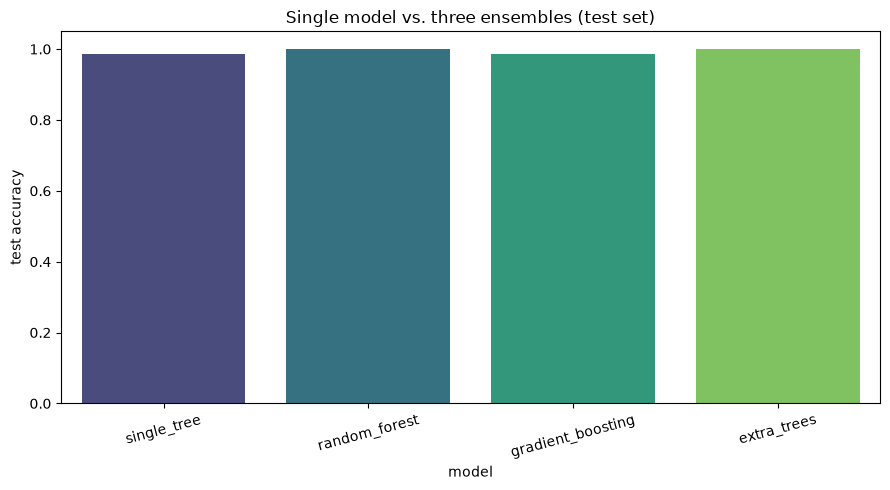

2026-07-31 20:26:58 | INFO | M05 | Best model: random_forest with test accuracy = 1.000


In [5]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same test set and chart the results.

WHY: The only fair comparison is on data none of the models used for training.
"""

# Score each model on the held-out test set.
acc_single_tree: float = float(accuracy_score(y_test, modelA.predict(X_test)))
acc_random_forest: float = float(accuracy_score(y_test, modelB.predict(X_test)))
acc_gradient_boosting: float = float(accuracy_score(y_test, modelC.predict(X_test)))
acc_extra_trees: float = float(accuracy_score(y_test, modelD.predict(X_test)))

LOG.info(f"  {'single_tree':18s} test accuracy = {acc_single_tree:.3f}")
LOG.info(f"  {'random_forest':18s} test accuracy = {acc_random_forest:.3f}")
LOG.info(f"  {'gradient_boosting':18s} test accuracy = {acc_gradient_boosting:.3f}")
LOG.info(f"  {'extra_trees':18s} test accuracy = {acc_extra_trees:.3f}")

# Store the results for charting and comparison.
scores: dict[str, float] = {
    "single_tree": acc_single_tree,
    "random_forest": acc_random_forest,
    "gradient_boosting": acc_gradient_boosting,
    "extra_trees": acc_extra_trees,
}

x_keys = list(scores.keys())
y_values = list(scores.values())

plt.figure(figsize=(9, 5))
sns.barplot(
    x=x_keys,
    y=y_values,
    hue=x_keys,
    palette="viridis",
    legend=False,
)
plt.ylim(0, 1.05)
plt.xlabel("model")
plt.ylabel("test accuracy")
plt.title("Single model vs. three ensembles (test set)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best: str = max(scores, key=scores.get)  # type: ignore[arg-type]
LOG.info(f"Best model: {best} with test accuracy = {scores[best]:.3f}")

### Interpretation

After running the notebook, compare the four held-out test scores:

- Did Extra Trees outperform the single decision tree?
- Did Extra Trees outperform Random Forest or Gradient Boosting?
- Was any improvement large enough to justify the added complexity?
- If two models tied, which model would be easier to explain or maintain?

## Section 6. Which Features Did the Forest Rely On?

2026-07-31 20:26:58 | INFO | M05 | Random forest feature importances (high to low):
2026-07-31 20:26:58 | INFO | M05 |   bill_length_mm       0.404
2026-07-31 20:26:58 | INFO | M05 |   flipper_length_mm    0.301
2026-07-31 20:26:58 | INFO | M05 |   bill_depth_mm        0.219
2026-07-31 20:26:58 | INFO | M05 |   body_mass_g          0.076


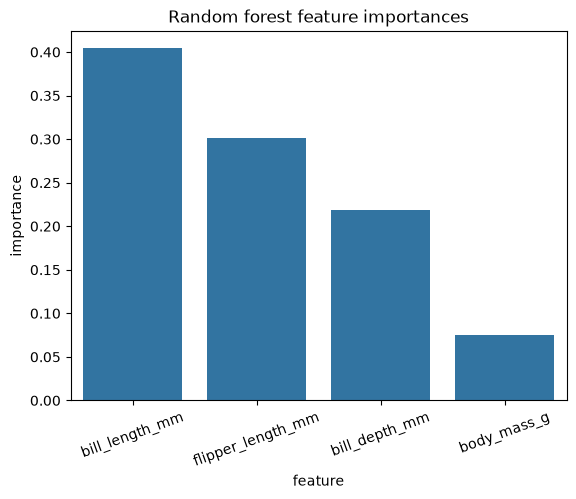

In [6]:
# === Section 6. Feature Importances (Random Forest) ===


"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue,
not proof of causation.

Interpret them with the same care as any other finding.
"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = modelB.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [7]:
# === Python Summary ===

"""Record what was compared and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (classification)")
LOG.info(
    "Compared: single tree vs. random forest vs. gradient boosting vs. extra trees"
)
LOG.info(f"Best model: {best} with test accuracy = {scores[best]:.3f}")
LOG.info("========================")

2026-07-31 20:26:58 | INFO | M05 | ========================
2026-07-31 20:26:58 | INFO | M05 | SUMMARY
2026-07-31 20:26:58 | INFO | M05 | ========================
2026-07-31 20:26:58 | INFO | M05 | Dataset: penguins   Target: species (classification)
2026-07-31 20:26:58 | INFO | M05 | Compared: single tree vs. random forest vs. gradient boosting vs. extra trees
2026-07-31 20:26:58 | INFO | M05 | Best model: random_forest with test accuracy = 1.000
2026-07-31 20:26:58 | INFO | M05 | ========================


### Analyst Judgment

After running all cells, the Random Forest was identified as the best model with a test accuracy of `1.000`. The Extra Trees model executed successfully and was included in the comparison, but it did not produce a higher accuracy than the Random Forest. Because the Random Forest already achieved perfect accuracy on the held-out test set, the added complexity of Extra Trees did not provide a clear improvement for this dataset. Based on these results, I would select the Random Forest while recognizing that cross-validation would provide stronger evidence of how well the model performs on new data.
